# SmartBank Customer Churn Analysis
### Lloyds Banking Group "Customer Retention Enhancement through Predictive Analytics" Initiative
### Analysis by: Breanna Williams
#### November 28, 2025

---
---
---
### Overview

This notebook contains the exploratory data analysis (EDA) and preprocessing steps for a Customer Churn Analysis for SmartBank. The goal of this project is to analyze customer data to identify patterns and factors that contribute to customer churn. The data was collected from the banks internal database and included demographic information, account activity, transaction history, customer churn, and customer service interactions. 

We performed EDA to understand the data distribution, identify missing values, and explore relationships between variables. Following EDA, we implemented preprocessing steps such as handling missing values, encoding categorical variables, scaling numeric features.

We found that that univariate analysis provided limited insights into churn predictors, indicating the need for multivariate modeling to uncover complex relationships.

---
### Necessary Libraries and Imports

In [32]:
# Base imports
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Stats imports
import pingouin as pg
from scipy.stats import pointbiserialr

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
sns.set_palette('Set1')

---
### Load Data

In [33]:
churn_status = pd.read_csv('../data/Customer_Churn_Data_Large(Churn_Status).csv')
customer_demographics = pd.read_csv('../data/Customer_Churn_Data_Large(Customer_Demographics).csv')
customer_service = pd.read_csv('../data/Customer_Churn_Data_Large(Customer_Service).csv')
online_activity = pd.read_csv('../data/Customer_Churn_Data_Large(Online_Activity).csv')
transaction_history = pd.read_csv('../data/Customer_Churn_Data_Large(Transaction_History).csv')

In [34]:
def transform_customer_service(customer_service):
    """
    Transforms the highly granular customer_service dataframe by:
     1. Encoding ResolutionStatus as binary,
     2. Grouping by CustomerID,
     3. Replacing individual interaction dates with DaysSinceLastInteraction and,
     4. Calculating new column ResolutionRate.
    """
    customer_service = pd.get_dummies(customer_service, columns=['InteractionType'], drop_first=True, dtype=int)

    # Binarize resolution status for grouping 
    customer_service['ResolutionStatus'] = customer_service['ResolutionStatus'].replace({'Unresolved': 0, 'Resolved': 1})

    # Convert InteractionDate to datetime
    customer_service['InteractionDate'] = pd.to_datetime(customer_service['InteractionDate'])

    # Group customer_service by CustomerID
    customer_service = customer_service.groupby('CustomerID').agg({
                                                'InteractionID': 'nunique',           
                                                'InteractionDate': 'max',
                                                'ResolutionStatus': 'sum',
                                                'InteractionType_Feedback': 'sum',
                                                'InteractionType_Inquiry': 'sum'
                                                }).reset_index().rename(columns={
                                                'InteractionID': 'NumInteractions', 
                                                'ResolutionStatus': 'InteractionsResolved'}) 

    # Calculate DaysSinceLastInteraction
    max_int_date = customer_service['InteractionDate'].max()
    customer_service['DaysSinceLastInteraction'] = (max_int_date - customer_service['InteractionDate']).dt.days

    # Creating a new column to indicate the rate of interactions resolved
    customer_service['ResolutionRate'] = round(customer_service['InteractionsResolved'] / customer_service['NumInteractions'], 2)

    customer_service['PctInteractionType_Feedback'] = (customer_service['InteractionType_Feedback'] / customer_service['NumInteractions']).round(2)

    customer_service['PctInteractionType_Inquiry'] = (customer_service['InteractionType_Inquiry'] / customer_service['NumInteractions']).round(2)

    # Drop raw date column
    customer_service.drop(columns=['InteractionDate', 'InteractionsResolved', 'InteractionType_Feedback', 'InteractionType_Inquiry'], inplace=True)     

    return customer_service


In [35]:
# Applying the customer service transformation function
customer_service = transform_customer_service(customer_service)
customer_service.head()

,CustomerID,NumInteractions,DaysSinceLastInteraction,ResolutionRate,PctInteractionType_Feedback,PctInteractionType_Inquiry
0,1,1,274,1.0,0.0,1.0
1,2,1,288,1.0,0.0,1.0
2,3,1,128,1.0,0.0,1.0
3,4,2,42,0.5,0.0,1.0
4,6,1,239,1.0,1.0,0.0


In [36]:
def transform_online_activity(online_activity):
    """    
    Transforms online_activity dataframe by:
     1. Grouping by CustomerID,
     2. Replacing LastLoginDate with DaysSinceLastLogin and,
     3. Encoding ServiceUsage as dummy variables.
     """
    
    # Get dummies for ServiceUsage so we can aggregate later if needed
    online_activity = pd.get_dummies(online_activity, columns=['ServiceUsage'], drop_first=True, dtype=int)

    # Convert LastLoginDate to datetime
    online_activity['LastLoginDate'] = pd.to_datetime(online_activity['LastLoginDate'])

    # Group online_activity by CustomerID
    online_activity = online_activity.groupby('CustomerID').agg({'LastLoginDate': 'max',
                                                                 'LoginFrequency': 'max',
                                                                 'ServiceUsage_Online Banking': 'sum',
                                                                 'ServiceUsage_Website': 'sum'}).reset_index()

    # Add column for days since last login instead of using raw dates
    max_log_date = online_activity['LastLoginDate'].max()
    online_activity['DaysSinceLastLogin'] = (max_log_date - online_activity['LastLoginDate']).dt.days

    online_activity['UsageRate_OnlineBanking'] = (online_activity['ServiceUsage_Online Banking'] / online_activity['LoginFrequency']).round(2)
    online_activity['UsageRate_Website'] = (online_activity['ServiceUsage_Website'] / online_activity['LoginFrequency']).round(2)

    online_activity.drop(columns=['LastLoginDate', 'ServiceUsage_Online Banking', 'ServiceUsage_Website'], inplace=True)   

    return online_activity

In [37]:
online_activity = transform_online_activity(online_activity)
online_activity.head()

,CustomerID,LoginFrequency,DaysSinceLastLogin,UsageRate_OnlineBanking,UsageRate_Website
0,1,34,71,0.0,0.00
1,2,5,26,0.0,0.20
2,3,3,46,0.0,0.33
3,4,2,128,0.0,0.50
4,5,41,65,0.0,0.02


In [38]:
def transform_transaction_history(transaction_history):
    """ 
    Transforms the highly granular transaction_history dataframe by:
     1. Getting dummies for ProductCategory,
     2. Grouping by CustomerID and,
     3. Replacing TransactionDate with DaysSinceLastTransaction.
    """
    # Get dummies for ProductCategory so we can aggregate later if needed
    transaction_history = pd.get_dummies(transaction_history, columns=['ProductCategory'], drop_first=True, dtype=int)

    # Convert TransactionDate to datetime
    transaction_history['TransactionDate'] = pd.to_datetime(transaction_history['TransactionDate'])
    
    # Group transaction_history by CustomerID
    transaction_history = transaction_history.groupby('CustomerID').agg({
                                                    'TransactionID': 'nunique',
                                                    'AmountSpent': 'sum',
                                                    'TransactionDate': 'max',
                                                    'ProductCategory_Clothing': 'sum',
                                                    'ProductCategory_Electronics': 'sum',
                                                    'ProductCategory_Furniture': 'sum',
                                                    'ProductCategory_Groceries': 'sum'
                                                    }).reset_index().rename(columns={'TransactionID': 'NumTransactions'})

    # Add column for days since last transaction instead of using raw dates
    max_date = transaction_history['TransactionDate'].max()
    transaction_history['DaysSinceLastTransaction'] = (max_date - transaction_history['TransactionDate']).dt.days

    for prodcat in ['ProductCategory_Clothing', 'ProductCategory_Electronics', 'ProductCategory_Furniture', 'ProductCategory_Groceries']:
        transaction_history[f'Pct{prodcat}'] = (transaction_history[prodcat] / transaction_history['NumTransactions']).round(2)

    transaction_history.drop(columns=['TransactionDate', 'ProductCategory_Clothing', 'ProductCategory_Electronics', 'ProductCategory_Furniture', 'ProductCategory_Groceries'], inplace=True)     # Drop raw date column
    
    return transaction_history

In [39]:
transaction_history = transform_transaction_history(transaction_history)
transaction_history.head()

,CustomerID,NumTransactions,AmountSpent,DaysSinceLastTransaction,PctProductCategory_Clothing,PctProductCategory_Electronics,PctProductCategory_Furniture,PctProductCategory_Groceries
0,1,1,416.50,279,0.00,1.00,0.00,0.00
1,2,7,1547.42,42,0.29,0.43,0.14,0.14
2,3,6,1702.98,84,0.17,0.00,0.33,0.33
3,4,5,917.29,4,0.20,0.40,0.20,0.20
4,5,8,2001.49,10,0.00,0.38,0.25,0.38


In [40]:
def merge_data(churn_status, customer_demographics, customer_service, online_activity, transaction_history):
    # Merge the datasets on 'CustomerID'
    data = churn_status.merge(customer_demographics, on='CustomerID', how='left') \
                         .merge(customer_service, on='CustomerID', how='left') \
                            .merge(online_activity, on='CustomerID', how='left') \
                                .merge(transaction_history, on='CustomerID', how='left')
    return data

In [41]:
data = merge_data(churn_status, customer_demographics, customer_service, online_activity, transaction_history)

---
### Clean Data

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      1000 non-null   int64  
 1   ChurnStatus                     1000 non-null   int64  
 2   Age                             1000 non-null   int64  
 3   Gender                          1000 non-null   object 
 4   MaritalStatus                   1000 non-null   object 
 5   IncomeLevel                     1000 non-null   object 
 6   NumInteractions                 668 non-null    float64
 7   DaysSinceLastInteraction        668 non-null    float64
 8   ResolutionRate                  668 non-null    float64
 9   PctInteractionType_Feedback     668 non-null    float64
 10  PctInteractionType_Inquiry      668 non-null    float64
 11  LoginFrequency                  1000 non-null   int64  
 12  DaysSinceLastLogin              100

In [43]:
# Converting categorical columns to appropriate types
for col in ['Gender', 'MaritalStatus', 'ChurnStatus']:
    data[col] = data[col].astype('category')

In [44]:
# Converting IncomeLevel to ordered categorical
data['IncomeLevel'] = pd.Categorical(data['IncomeLevel'], categories=['Low', 'Medium', 'High'], ordered=True)

In [45]:
# Checking for duplicates
data.duplicated().sum()

0

In [46]:
# Checking summary statistics
data.describe().round(2)

,CustomerID,Age,NumInteractions,DaysSinceLastInteraction,ResolutionRate,PctInteractionType_Feedback,PctInteractionType_Inquiry,LoginFrequency,DaysSinceLastLogin,UsageRate_OnlineBanking,UsageRate_Website,NumTransactions,AmountSpent,DaysSinceLastTransaction,PctProductCategory_Clothing,PctProductCategory_Electronics,PctProductCategory_Furniture,PctProductCategory_Groceries
count,1000.00,1000.00,668.0,668.00,668.00,668.00,668.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,43.27,1.5,151.14,0.53,0.35,0.32,25.91,178.10,0.03,0.03,5.05,1267.07,78.05,0.20,0.20,0.19,0.21
std,288.82,15.24,0.5,98.10,0.42,0.42,0.41,14.06,104.90,0.09,0.09,2.60,738.59,78.72,0.22,0.23,0.21,0.23
min,1.00,18.00,1.0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,9.80,0.00,0.00,0.00,0.00,0.00
25%,250.75,30.00,1.0,64.00,0.00,0.00,0.00,13.75,90.75,0.00,0.00,3.00,626.68,20.00,0.00,0.00,0.00,0.00
50%,500.50,43.00,1.5,144.50,0.50,0.00,0.00,27.00,173.50,0.00,0.00,5.00,1232.88,52.00,0.14,0.14,0.14,0.17
75%,750.25,56.00,2.0,225.25,1.00,0.50,0.50,38.00,267.00,0.03,0.02,7.00,1791.90,106.00,0.33,0.33,0.33,0.33
max,1000.00,69.00,2.0,359.00,1.00,1.00,1.00,49.00,364.00,1.00,1.00,9.00,3386.04,355.00,1.00,1.00,1.00,1.00


In [47]:
# Checking skewness of numeric features to determine if transformations are needed before modeling
num_skewness = []
for col in data.select_dtypes(include=['number']).columns:
    skew = data[col].skew()
    num_skewness.append({'column': col, 'skew': skew, 'direction': 'right' if skew > 0 else 'left',
                         'distribution': 'approximately normal' if abs(skew) < 0.5 else 'moderately skewed' if abs(skew) < 1 else 'highly skewed'})

pd.DataFrame(num_skewness)

,column,skew,direction,distribution
0,CustomerID,0.000000,left,approximately normal
1,Age,0.013168,right,approximately normal
2,NumInteractions,0.000000,left,approximately normal
3,DaysSinceLastInteraction,0.300352,right,approximately normal
4,ResolutionRate,-0.105197,left,approximately normal
5,PctInteractionType_Feedback,0.607575,right,moderately skewed
6,PctInteractionType_Inquiry,0.768205,right,moderately skewed
7,LoginFrequency,-0.127877,left,approximately normal
8,DaysSinceLastLogin,0.080321,right,approximately normal
9,UsageRate_OnlineBanking,7.934933,right,highly skewed


In [48]:
# Checking for outliers
for col in data.select_dtypes(include=['number']).columns:
    q1 = np.percentile(data[col], 25)
    q3 = np.percentile(data[col], 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = data[col][(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(f'{col}: {len(outliers)} outliers')

CustomerID: 0 outliers
Age: 0 outliers
NumInteractions: 0 outliers
DaysSinceLastInteraction: 0 outliers
ResolutionRate: 0 outliers
PctInteractionType_Feedback: 0 outliers
PctInteractionType_Inquiry: 0 outliers
LoginFrequency: 0 outliers
DaysSinceLastLogin: 0 outliers
UsageRate_OnlineBanking: 78 outliers
UsageRate_Website: 103 outliers
NumTransactions: 0 outliers
AmountSpent: 0 outliers
DaysSinceLastTransaction: 66 outliers
PctProductCategory_Clothing: 27 outliers
PctProductCategory_Electronics: 34 outliers
PctProductCategory_Furniture: 23 outliers
PctProductCategory_Groceries: 36 outliers


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   CustomerID                      1000 non-null   int64   
 1   ChurnStatus                     1000 non-null   category
 2   Age                             1000 non-null   int64   
 3   Gender                          1000 non-null   category
 4   MaritalStatus                   1000 non-null   category
 5   IncomeLevel                     1000 non-null   category
 6   NumInteractions                 668 non-null    float64 
 7   DaysSinceLastInteraction        668 non-null    float64 
 8   ResolutionRate                  668 non-null    float64 
 9   PctInteractionType_Feedback     668 non-null    float64 
 10  PctInteractionType_Inquiry      668 non-null    float64 
 11  LoginFrequency                  1000 non-null   int64   
 12  DaysSinceLastLogin   

##### Insights:
- The dataset contains 1000 records and 22 features after feature engineering (dtypes: category (4), float(12), int(6)).
- DaysSinceLastInteraction, ResolutionRate, PctInteractionType_Feedback, and PctInteractionType_Inquiry have meaningful NA's that we will handle during preprocessing.
- There are varying scales between variables, which we will address during preprocessing.
- There are several variables that have moderate-high skewness in towards the right, which will require handling during preprocessing before modeling.
- There are several variables with outliers, which will be addressed during preprocessing.
---

### Univariate Statistical(Regression) Analysis
We will conduct hypothesis testing to identify which features are significantly associated with the target variable 'ChurnStatus'. Since 'ChurnStatus' is binary, we will use point-biserial correlation for continuous features and chi-squared tests for categorical features.

#### Chi-Square Test for Categorical Variables:
Since our target variable 'CustomerChurn' is binary, we can use the chi-square test of independence to assess the association between categorical features and churn status. 

The null and alternative hypotheses for this test are:
- H0: The categorical feature variable is independent from ChurnStatus.
- HA: The categorical feature variable is associated with ChurnStatus.
- Significance Level: 0.05

In [50]:
# Seperating out the categorical columns for chi-square test analysis
cat_cols = data.select_dtypes(include='category').columns.tolist()

In [51]:
# Let's check for associations between categorical features and churn status using chi-squared tests.

chi2_results = []
alpha = 0.05

for col in cat_cols:
    if col != 'ChurnStatus':  # Skip the target variable
        expected, observed, stats = pg.chi2_independence(data=data, x=col, y='ChurnStatus')
        pearson = stats.loc[stats['test'] == 'pearson'].iloc[0]

        if pearson['pval'] < alpha:
            chi2_results.append({
                'Feature': col,
                'chi2': round(pearson['chi2'], 2),
                'effect_size': round(pearson['cramer'], 2),
                'pvalue': round(pearson['pval'], 4),
                'Significance': 'Significant'
            })

chi2_results_df = pd.DataFrame(chi2_results)

if chi2_results_df.empty:
    print('No categorical features were significant at alpha=0.05.')
else:
    chi2_results_df = chi2_results_df.sort_values(by='chi2', ascending=False).reset_index(drop=True)

chi2_results_df

No categorical features were significant at alpha=0.05.


""


##### Chi-Square Test Results:
The results of the chi-square tests indicate that there are no significant categorical features, leading us to fail to reject the null hypothesis. The categorical features appear to be independent from ChurnStatus.

#### Point-Biserial Correlation for Continuous Variables:
For continuous features, we will use point-biserial correlation to assess the strength and direction of the association between each continuous feature and the binary target variable 'ChurnStatus'. 

The null and alternative hypotheses for this test are:
- H0: There is no association between the numeric variable and the binary variable (the correlation coefficient is zero).
- H1: There is an association between the numeric variable and the binary variable (the correlation coefficient is not zero).

In [52]:
# Seperating out the numeric columns for point-biserial correlation analysis
num_cols = data.select_dtypes(exclude='category').columns.tolist()

In [53]:
num_cols

['CustomerID',
 'Age',
 'NumInteractions',
 'DaysSinceLastInteraction',
 'ResolutionRate',
 'PctInteractionType_Feedback',
 'PctInteractionType_Inquiry',
 'LoginFrequency',
 'DaysSinceLastLogin',
 'UsageRate_OnlineBanking',
 'UsageRate_Website',
 'NumTransactions',
 'AmountSpent',
 'DaysSinceLastTransaction',
 'PctProductCategory_Clothing',
 'PctProductCategory_Electronics',
 'PctProductCategory_Furniture',
 'PctProductCategory_Groceries']

In [54]:
point_bi_results = []
alpha = 0.05
for col in num_cols:
    if col != 'ChurnStatus' and col != 'CustomerID':
        temp_df = data[['ChurnStatus', col]].replace([np.inf, -np.inf], np.nan).dropna()
        corr, p_value = pointbiserialr(temp_df['ChurnStatus'], temp_df[col])
        if p_value < alpha:
            point_bi_results.append({
                    'Feature': col,
                    'Correlation': corr.round(2),
                    'pvalue': p_value.round(4),
                    'Significance': 'Significant' if p_value < alpha else 'Not Significant'
                })

point_bi_results_df = pd.DataFrame(point_bi_results).sort_values(by='Correlation', ascending=False, key=lambda x: abs(x)).reset_index(drop=True)
point_bi_results_df

,Feature,Correlation,pvalue,Significance
0,DaysSinceLastInteraction,0.12,0.0020,Significant
1,LoginFrequency,-0.08,0.0098,Significant


##### Point-Biserial Test Results:
The point-biserial correlation analysis revealed that two numeric features have a statistically significant association with ChurnStatus. However, the correlations were generally weak, indicating that while there may be some relationship between these features and churn, they are not strong predictors on their own. The features with significant associations include (ordered by absolute correlation coefficient):
1. DaysSinceLastInteraction
2. LoginFrequency

In [55]:
# Saving the significant numeric features to a list for visualization
sig_num = point_bi_results_df['Feature'].tolist()

---
### Exploratory Data Analysis (EDA) of Significant Variables

#### Target Variable (ChurnStatus)

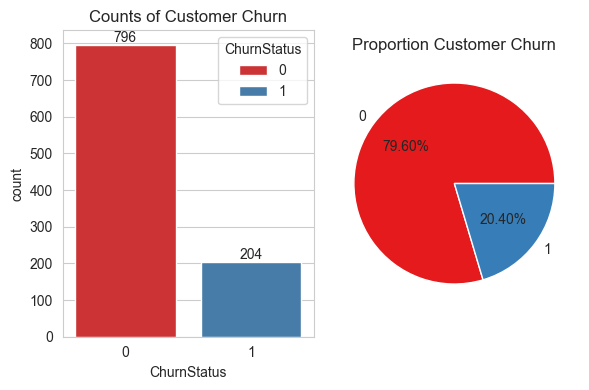

In [56]:
# Visualizing the distribution of the target variable
fig, axs = plt.subplots(1, 2, figsize=(6,4))

# Countplot with hue to show the distribution of churn status
sns.countplot(data=data, x='ChurnStatus', hue='ChurnStatus', ax=axs[0])
for container in axs[0].containers:     # Loop needed when hue is used.
    axs[0].bar_label(container)
axs[0].set_title('Counts of Customer Churn')

# Pie chart to show the proportion of churned vs non-churned customers
counts = data['ChurnStatus'].value_counts()
axs[1].pie(counts, labels=counts.index, autopct='%0.2f%%')
axs[1].set_title('Proportion Customer Churn')

plt.tight_layout()
plt.show()


##### Target Variable Exploration Insights:
- The target variable is imbalanced as evidenced by an over 60% difference between customers who churned and those who did not churn.
- We will need to take this into account when preparing the data for modeling.

#### EDA of Significant **Numeric** Features:

In [57]:
# Viewing the summary statistics of the significant numeric features to understand their distributions and potential outliers before visualizing them.
data[sig_num].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
DaysSinceLastInteraction,668.0,151.14,98.10,0.0,64.00,144.5,225.25,359.0
LoginFrequency,1000.0,25.91,14.06,1.0,13.75,27.0,38.00,49.0


In [58]:
# Checking skewness of significant numeric features
num_skewness = []
for col in data[sig_num]:
    skew = data[col].skew()
    num_skewness.append({'column': col, 'skew': skew, 'direction': 'right' if skew > 0 else 'left',
                         'distribution': 'approximately normal' if abs(skew) < 0.5 else 'moderately skewed' if abs(skew) < 1 else 'highly skewed'})

pd.DataFrame(num_skewness)

,column,skew,direction,distribution
0,DaysSinceLastInteraction,0.300352,right,approximately normal
1,LoginFrequency,-0.127877,left,approximately normal


In [59]:
# Checking for outliers
for col in data[sig_num]:
    q1 = np.percentile(data[col], 25)
    q3 = np.percentile(data[col], 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    outliers = data[col][(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(f'{col}: {len(outliers)} outliers')

DaysSinceLastInteraction: 0 outliers
LoginFrequency: 0 outliers


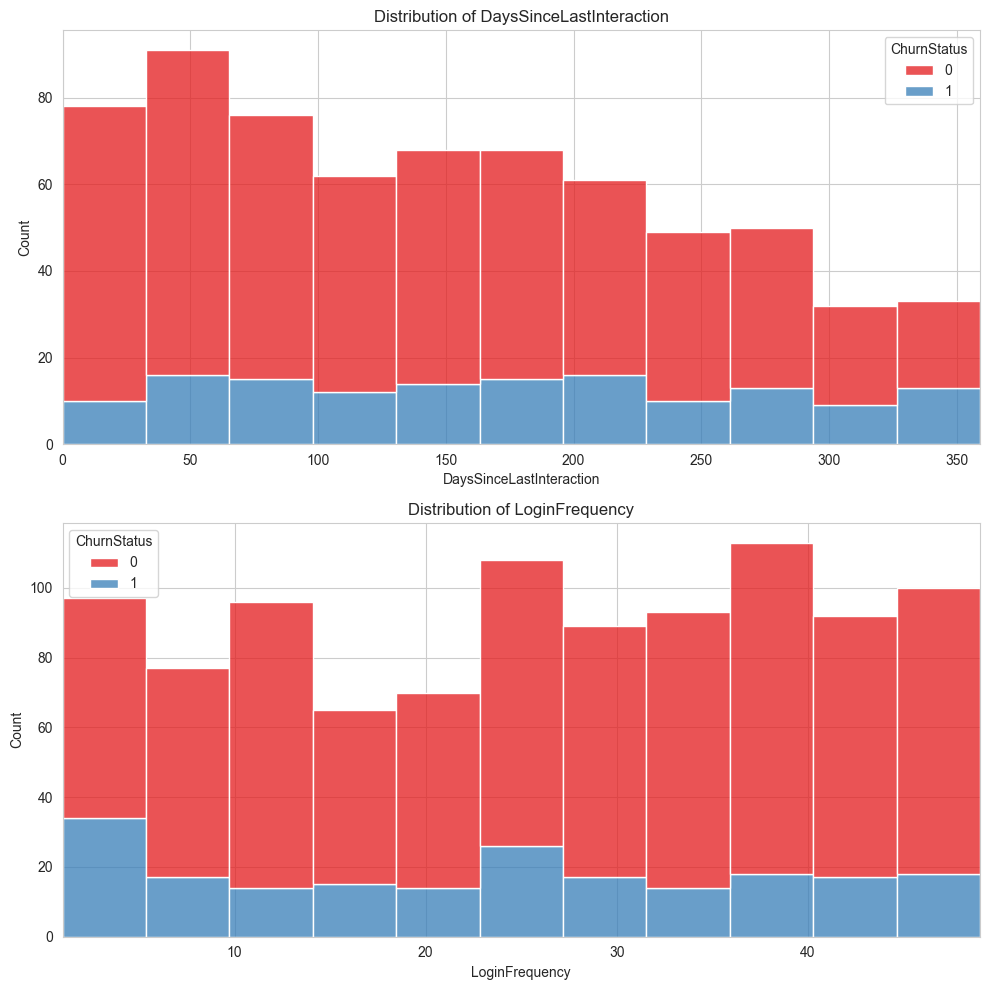

In [60]:
# Visualizing the distribution of the significant numeric features with histograms and hue to show the distribution of churn status within each feature.
fig, axs = plt.subplots(nrows=len(sig_num), ncols=1, figsize=(10, 5 * len(sig_num)))
for i, col in enumerate(sig_num):
    sns.histplot(data=data, x=col, hue='ChurnStatus', ax=axs[i], multiple='stack')
    axs[i].set_title(f'Distribution of {col}')
    axs[i].set_xlim([data[col].min(), data[col].max()])
plt.tight_layout()
plt.show()

##### Numeric Feature Exploration Insights
- The ranges of the numeric features are dissimilar which will need to be taken into account by normalizing or standardizing the data during preprocessing.
- Both significant numeric features are approximately normally distributed with no outliers detected.
- There appears to be little to no relationship between the significant numeric features and churn status, as evidenced by the similar distributions of churned and non-churned customers across the range of each feature.

---
### Download Clean Data Set for Modeling

In [61]:
# Let's Save for preprocessing
data.to_csv('../data/clean_customer_churn_data.csv', index=False)

---
### Final Comments:
- EDA and preprocessing are complete. However, EDA insights indicate that there are no strong univariate predictors of churn.
- We will need to explore multivariate models during our modeling phase to better understand the drivers of churn.

---
---
---